In [ ]:
!pip uninstall -y tensorflow tensorflow-gpu tf-nightly >pip_out.log 2>pip_err.log
!pip install -U protobuf==3.20.3 >pip_out.log 2>pip_err.log
!pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu118 2>pip_err.log >pip_out.log
!pip install numpy==2.0.2 -q 2>pip_err.log >pip_out.log
!pip install nnsight -q 2>pip_err.log >pip_out.log

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Looped transformer architecture
d_model = 128


In [ ]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import time
import matplotlib.pyplot as plt

# ==========================================
# 1. DATASET DEFINITION
# ==========================================
class SudokuDataset(Dataset):
    def __init__(self, csv_file, max_samples=10000, start=0):
        """
        Loads the Kaggle Sudoku dataset.
        Columns expected: 'puzzle', 'solution' (81 character strings)
        """
        self.data = pd.read_csv(csv_file, nrows=max_samples, skiprows=range(1, start) if start != 0 else 0)
        self.vocab_size = 10  # 0=blank/unknown, 1-9=digits (No BOS/EOS needed for parallel refinement)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        quiz_str = str(self.data.iloc[idx]['puzzle'])
        sol_str = str(self.data.iloc[idx]['solution'])

        quiz = torch.tensor([int(c) for c in quiz_str], dtype=torch.long)
        sol = torch.tensor([int(c) for c in sol_str], dtype=torch.long)
        return quiz, sol

# ==========================================
# 2. 3D STRUCTURAL POSITIONAL ENCODINGS
# ==========================================
class Sudoku3DPositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        # 9 unique indices each for rows, columns, and 3x3 boxes
        self.row_embed = nn.Embedding(9, d_model)
        self.col_embed = nn.Embedding(9, d_model)
        self.box_embed = nn.Embedding(9, d_model)

        # Precompute grid coordinates mapping for all 81 positions
        rows = torch.arange(81) // 9
        cols = torch.arange(81) % 9
        boxes = (rows // 3) * 3 + (cols // 3)

        self.register_buffer('rows', rows)
        self.register_buffer('cols', cols)
        self.register_buffer('boxes', boxes)

    def forward(self, x):
        # x shape: (batch_size, 81, d_model)
        grid_pos_encoding = (
            self.row_embed(self.rows) +
            self.col_embed(self.cols) +
            self.box_embed(self.boxes)
        ) # Shape: (81, d_model)
        return x + grid_pos_encoding.unsqueeze(0)

# ==========================================
# 3. RECURRENT TRANSFORMER ARCHITECTURE
# ==========================================
class RecurrentSudokuTransformer(nn.Module):
    def __init__(self, vocab_size=10, d_model=128, nhead=4, num_steps=8):
        super().__init__()
        self.num_steps = num_steps  # Computational refinement iterations

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = Sudoku3DPositionalEncoding(d_model)

        # A single shared encoder layer that is applied recurrently
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            batch_first=True,
            norm_first=True
        )
        self.transformer_block = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, src):
        # src shape: (batch_size, 81)
        x = self.token_embedding(src) * math.sqrt(src.size(-1))
        x = self.pos_encoder(x)

        # Recurrent execution loop: pass data through the same block multiple times
        for _ in range(self.num_steps):
            x = self.transformer_block(x)

        return self.fc_out(x) # Shape: (batch_size, 81, vocab_size)

# ==========================================
# 4. CARDINALITY CONSTRAINT LOSS (CSP)
# ==========================================
class CardinalityConstraintLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # Precalculate index masks for rows, columns, and 3x3 boxes over 81 elements
        self.row_indices = [list(range(i * 9, (i + 1) * 9)) for i in range(9)]
        self.col_indices = [list(range(j, 81, 9)) for j in range(9)]

        self.box_indices = []
        for box_row in range(3):
            for box_col in range(3):
                box = []
                for r in range(box_row * 3, (box_row + 1) * 3):
                    for c in range(box_col * 3, (box_col + 1) * 3):
                        box.append(r * 9 + c)
                self.box_indices.append(box)

    def forward(self, logits):
        # logits shape: (batch_size, 81, vocab_size)
        probs = torch.softmax(logits, dim=-1)
        # Extract probabilities for valid sudoku digits 1 to 9 (ignore index 0)
        digit_probs = probs[:, :, 1:10] # Shape: (batch_size, 81, 9)

        loss = 0.0

        # Penalize duplicate digits within rows
        for indices in self.row_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1) # Sum over the 9 cells in the row
            loss += torch.mean((group_sum - 1.0) ** 2)

        # Penalize duplicate digits within columns
        for indices in self.col_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1)
            loss += torch.mean((group_sum - 1.0) ** 2)

        # Penalize duplicate digits within 3x3 boxes
        for indices in self.box_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1)
            loss += torch.mean((group_sum - 1.0) ** 2)

        return loss / 27.0 # Normalized across all 27 unit constraints

# ==========================================
# 5. EXECUTION PIPELINE
# ==========================================
def train_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Model Hyperparameters
    d_model = 128
    nhead = 4
    num_steps = 6  # Recurrent depth per pass
    batch_size = 64
    epochs = 100

    # Load Datasets (Replace paths with your specific setup)
    csv_path = '/content/drive/MyDrive/Colab Notebooks/sudoku.csv'
    try:
        train_set = SudokuDataset(csv_path, max_samples=10000)
        val_set = SudokuDataset(csv_path, start=10000, max_samples=2000)
    except FileNotFoundError:
        print("Dataset path not found. Please verify your file location.")
        return

    dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    model = RecurrentSudokuTransformer(vocab_size=10, d_model=d_model, nhead=nhead, num_steps=num_steps).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

    # Combined supervised classification loss + CSP alignment loss
    ce_criterion = nn.CrossEntropyLoss()
    csp_criterion = CardinalityConstraintLoss()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    print(f"Training started on device: {device}")

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        correct_train_digits = 0
        total_train_digits = 0

        for src, target in dataloader:
            src, target = src.to(device), target.to(device)

            optimizer.zero_grad()
            logits = model(src) # Direct parallel prediction

            # Supervised Cross Entropy loss matching ground truth
            loss_ce = ce_criterion(logits.view(-1, 10), target.view(-1))
            # Auxiliary constraint validation loss
            loss_csp = csp_criterion(logits)

            # Combined Loss Weighting
            loss = loss_ce + 0.5 * loss_csp
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            # Track precision metrics
            preds = logits.argmax(dim=-1)
            correct_train_digits += (preds == target).sum().item()
            total_train_digits += target.numel()

        avg_train_loss = total_train_loss / len(dataloader)
        train_acc = correct_train_digits / total_train_digits
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # Validation Pass
        model.eval()
        total_val_loss = 0
        correct_val_digits = 0
        total_val_digits = 0

        with torch.no_grad():
            for src, target in val_loader:
                src, target = src.to(device), target.to(device)
                logits = model(src)

                loss_ce = ce_criterion(logits.view(-1, 10), target.view(-1))
                loss_csp = csp_criterion(logits)
                loss = loss_ce + 0.5 * loss_csp

                total_val_loss += loss.item()
                preds = logits.argmax(dim=-1)
                correct_val_digits += (preds == target).sum().item()
                total_val_digits += target.numel()

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = correct_val_digits / total_val_digits
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Digit Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Digit Acc: {val_acc*100:.2f}%")

# ==========================================
    # 6. PLOTTING METRICS (WITH PLOTLY)
    # ==========================================
    import plotly.express as px
    import pandas as pd

    # 1. Plotting the Loss
    df_loss = pd.DataFrame({
        'Epoch': list(range(1, epochs + 1)) * 2,
        'Loss': train_losses + val_losses,
        'Split': ['Train'] * epochs + ['Validation'] * epochs
    })

    fig_loss = px.line(df_loss, x='Epoch', y='Loss', color='Split',
                       title='Loss Progression vs. Epoch (CE + CSP Loss)')
    fig_loss.show()

    # 2. Plotting the Accuracy
    df_acc = pd.DataFrame({
        'Epoch': list(range(1, epochs + 1)) * 2,
        'Accuracy': train_accuracies + val_accuracies,
        'Split': ['Train'] * epochs + ['Validation'] * epochs
    })

    fig_acc = px.line(df_acc, x='Epoch', y='Accuracy', color='Split',
                      title='Digit Accuracy vs. Epoch')
    fig_acc.show()

if __name__ == "__main__":
    train_pipeline()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Training started on device: cuda
Epoch 01/100 | Train Loss: 1.6576 | Train Digit Acc: 52.44% | Val Loss: 1.2435 | Val Digit Acc: 55.45%
Epoch 02/100 | Train Loss: 1.2408 | Train Digit Acc: 55.56% | Val Loss: 1.2184 | Val Digit Acc: 56.52%
Epoch 03/100 | Train Loss: 1.2297 | Train Digit Acc: 56.09% | Val Loss: 1.2166 | Val Digit Acc: 56.58%
Epoch 04/100 | Train Loss: 1.2268 | Train Digit Acc: 56.17% | Val Loss: 1.2159 | Val Digit Acc: 56.62%
Epoch 05/100 | Train Loss: 1.2242 | Train Digit Acc: 56.28% | Val Loss: 1.2145 | Val Digit Acc: 56.69%
Epoch 06/100 | Train Loss: 1.2221 | Train Digit Acc: 56.36% | Val Loss: 1.2125 | Val Digit Acc: 56.80%
Epoch 07/100 | Train Loss: 1.2193 | Train Digit Acc: 56.54% | Val Loss: 1.2082 | Val Digit Acc: 56.99%
Epoch 08/100 | Train Loss: 1.2093 | Train Digit Acc: 56.87% | Val Loss: 1.1875 | Val Digit Acc: 57.65%
Epoch 09/100 | Train Loss: 1.1528 | Train Digit Acc: 58.10% | Val Loss: 1.0807 | Val Digit Acc: 59.47%
Epoch 10/100 | Train Loss: 0.9990 | Trai

## Interpretability tooling
- Find more about NN Sight here - https://nnsight.net/

In [ ]:
!pip install nnsight -q 2>pip_err.log >pip_out.log

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from nnsight import NNsight

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


In [ ]:
# 1. Initialize the dataset to get a sample
dataset = SudokuDataset('/content/drive/MyDrive/Colab Notebooks/sudoku.csv', max_samples=100)
sample_src, sample_tgt = dataset[0]

# Add batch dimension and move to device
# Shape becomes (1, 81) for both source and target
sample_src = sample_src.unsqueeze(0).to(device)
sample_tgt = sample_tgt.unsqueeze(0).to(device)


# 2. Load the trained Recurrent model
# Using the exact hyperparameters from your training pipeline
vocab_size = 10
d_model = 128
nhead = 4
num_steps = 6

model = RecurrentSudokuTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    nhead=nhead,
    num_steps=num_steps
).to(device)

# Load your saved weights
model.eval()

# 3. Wrap the model nsight for interpretability
interpretable_model = NNsight(model)
print("Recurrent model wrapped with nnsight successfully!")

Recurrent model wrapped with nnsight successfully!


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:382: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True



### Come up with reasonable metrics and Ground truth/ baseline you want to compare with
- Entropy is given as a starting point

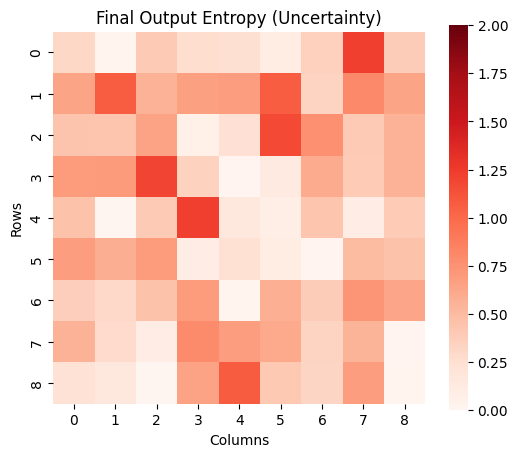

In [ ]:
def calculate_entropy(logits):
    probs = F.softmax(logits, dim=-1)
    entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=-1)
    return entropy

def plot_sudoku_heatmap(data_1d, title="Sudoku Grid Heatmap", cmap='Reds', vmin=0.0, vmax=2.0):
    grid = data_1d.view(9, 9).detach().cpu().numpy()
    plt.figure(figsize=(6, 5))
    # Locked scale prevents the visual illusion of colors shifting between steps
    sns.heatmap(grid, annot=False, cmap=cmap, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()

# Run the model normally to get the final logits
with torch.no_grad():

    final_logits = model(sample_src)

# Calculate entropy for the first sequence in the batch
entropy = calculate_entropy(final_logits[0])

# Plot
plot_sudoku_heatmap(entropy, title="Final Output Entropy (Uncertainty)", cmap="Reds", )

### Logit Lens

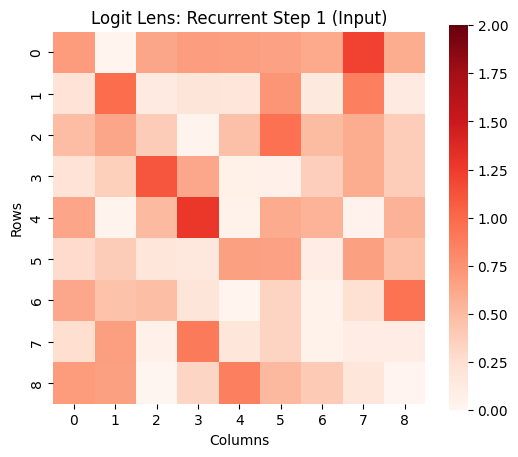

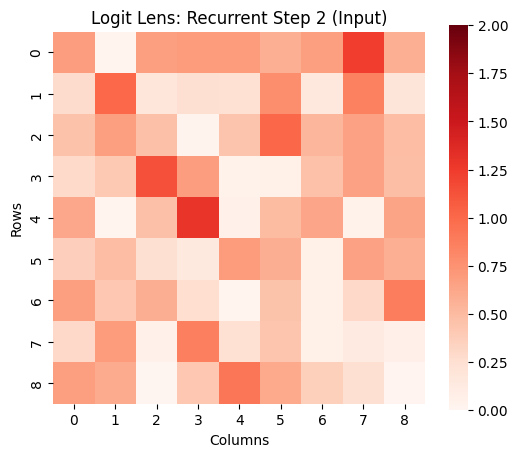

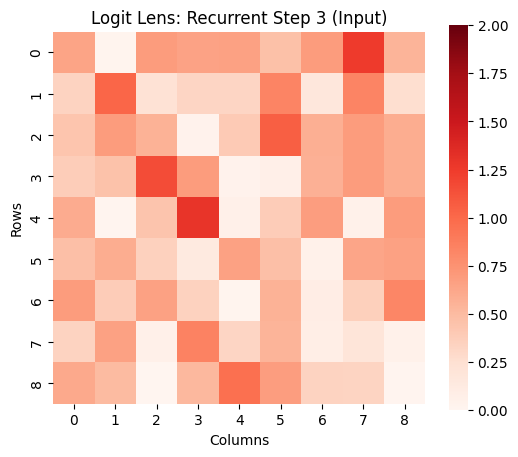

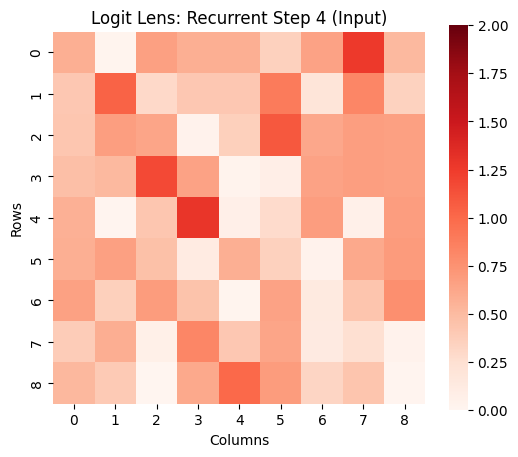

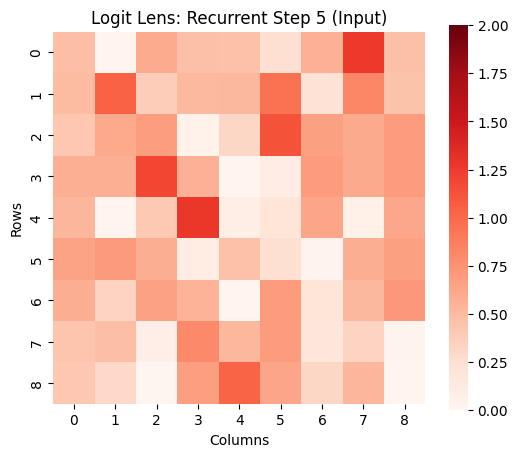

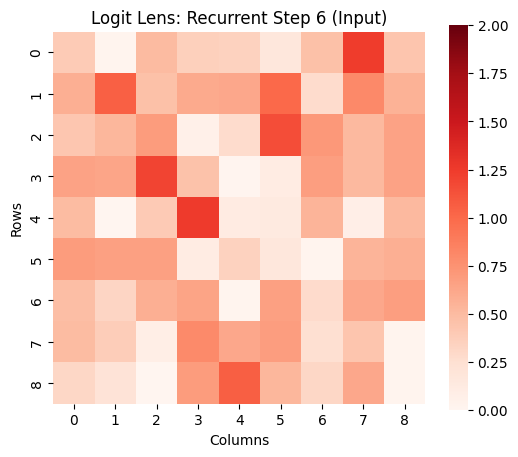

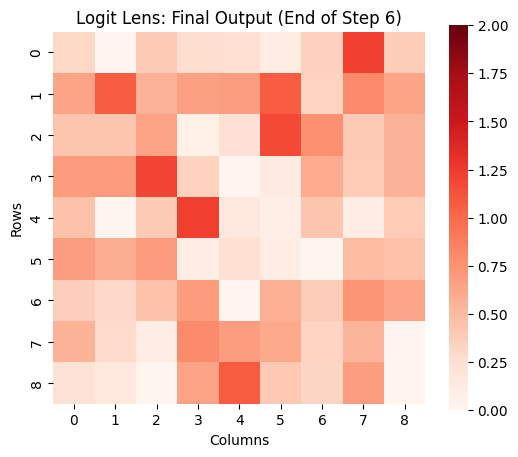

In [ ]:
# ==========================================
# 1. PLOTTING FUNCTION
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def plot_sudoku_heatmap(data_1d, title="Sudoku Grid Heatmap", cmap='Reds', vmin=0.0, vmax=2.3):
    grid = data_1d.view(9, 9).detach().cpu().numpy()
    plt.figure(figsize=(6, 5))
    # Locked scale prevents the visual illusion of colors shifting between steps
    sns.heatmap(grid, annot=False, cmap=cmap, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()

# ==========================================
# 2. RECURRENT LOGIT LENS
# ==========================================
layer_inputs = []
layer_outputs = []

# Define the wiretaps
def capture_input_hook(module, args):
    # args[0] is the data right before it enters the transformer block
    layer_inputs.append(args[0].detach().clone())

def capture_output_hook(module, args, output):
    # output is the data right after it exits the transformer block
    layer_outputs.append(output.detach().clone())

# Attach the wiretaps to your specific recurrent block
h1 = model.transformer_block.register_forward_pre_hook(capture_input_hook)
h2 = model.transformer_block.register_forward_hook(capture_output_hook)

# Run the model normally (the hooks will silently collect the data in the background)
with torch.no_grad():
    final_logits = model(sample_src)

# Remove the wiretaps (crucial so they don't leak memory later)
h1.remove()
h2.remove()

# Combine the data: We want the input at every step, PLUS the very final output
layer_hidden_states = layer_inputs + [layer_outputs[-1]]

# ==========================================
# 3. APPLY UNEMBEDDING AND PLOT
# ==========================================
for i, hidden_state in enumerate(layer_hidden_states):
    # Pass the intercepted hidden state through the final linear layer
    projected_logits = model.fc_out(hidden_state)

    # Calculate entropy for this specific time step
    layer_entropy = calculate_entropy(projected_logits[0])

    # Generate labels dynamically
    if i < len(layer_hidden_states) - 1:
        label = f"Logit Lens: Recurrent Step {i+1} (Input)"
    else:
        label = f"Logit Lens: Final Output (End of Step {model.num_steps})"

    # Explicitly pass the vmin and vmax limits to lock the colors
    plot_sudoku_heatmap(layer_entropy, title=label, cmap="Reds", vmin=0.0, vmax=2)

### Attention heat maps
- Sample for encoder attention heat map.
- That might not be what you would really want to look at. Think and do.

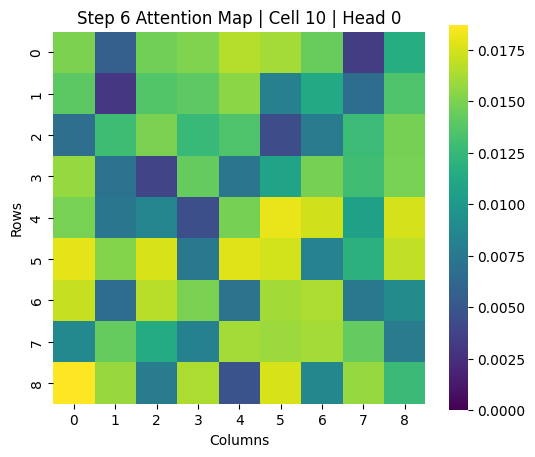

In [ ]:
import torch.nn.functional as F
import math

# ==========================================
# 1. INTERCEPT THE ATTENTION INPUTS
# ==========================================
# Grab the dataset again in the global scope
dataset = SudokuDataset('/content/drive/MyDrive/Colab Notebooks/sudoku.csv', max_samples=10)

# Define test_src so the wiretap has something to intercept
test_src, _ = dataset[0]
captured_attn_inputs = []

def capture_self_attn_hook(module, args):
    # args[0] is the 'query' input. In self-attention, query=key=value.
    # Because of the loop, this hook will fire 6 times per forward pass.
    captured_attn_inputs.append(args[0].detach().clone())

# Attach the wiretap directly to the single recurrent attention layer
attn_layer = model.transformer_block.layers[0].self_attn
h_attn = attn_layer.register_forward_pre_hook(capture_self_attn_hook)

# Run a single board through the model (make sure sample_src is shape [1, 81])
with torch.no_grad():
    _ = model(test_src.unsqueeze(0).to(device))

# Remove the wiretap
h_attn.remove()

# Extract the data from the FINAL step of the 6-loop cycle
final_step_input = captured_attn_inputs[-1] # Shape: (1, 81, 128)

# ==========================================
# 2. MANUALLY CALCULATE ATTENTION
# ==========================================
# Get the packed weights straight from your model
in_proj_weight = attn_layer.in_proj_weight
in_proj_bias = attn_layer.in_proj_bias

# Manually project the input into Q, K, and V (Shape becomes [1, 81, 384])
qkv = F.linear(final_step_input, in_proj_weight, in_proj_bias)
q, k, v = qkv.chunk(3, dim=-1)

# Reshape for multi-head attention
# d_model = 128, nhead = 4 -> head_dim = 32
batch_size, seq_len, _ = final_step_input.shape
nhead = model.transformer_block.layers[0].self_attn.num_heads
head_dim = q.size(-1) // nhead

# Shape becomes: [batch_size, nhead, seq_len, head_dim] -> [1, 4, 81, 32]
q = q.view(batch_size, seq_len, nhead, head_dim).transpose(1, 2)
k = k.view(batch_size, seq_len, nhead, head_dim).transpose(1, 2)

# Compute Attention Scores: (Q * K^T) / sqrt(d_k)
attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)
attn_probs = F.softmax(attn_scores, dim=-1)

# ==========================================
# 3. PLOT THE RESULTS
# ==========================================
# Let's look at what Cell 10 (Row 1, Col 1) is paying attention to
token_idx = 10
head_idx = 0   # Pick one of the 4 heads to investigate (0, 1, 2, or 3)

# Extract the 81 attention probabilities for this specific cell and head
token_attn = attn_probs[0, head_idx, token_idx, :].detach().cpu()

# Plot it! (We set vmin=0 to lock the floor, but let seaborn handle vmax automatically
# so the peaks pop out visually)
plot_sudoku_heatmap(
    token_attn,
    title=f"Step {model.num_steps} Attention Map | Cell {token_idx} | Head {head_idx}",
    cmap="viridis",
    vmin=0.0,
    vmax=None
)

d_model = 256

In [ ]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import time
import matplotlib.pyplot as plt

# ==========================================
# 1. DATASET DEFINITION
# ==========================================
class SudokuDataset(Dataset):
    def __init__(self, csv_file, max_samples=10000, start=0):
        """
        Loads the Kaggle Sudoku dataset.
        Columns expected: 'puzzle', 'solution' (81 character strings)
        """
        self.data = pd.read_csv(csv_file, nrows=max_samples, skiprows=range(1, start) if start != 0 else 0)
        self.vocab_size = 10  # 0=blank/unknown, 1-9=digits (No BOS/EOS needed for parallel refinement)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        quiz_str = str(self.data.iloc[idx]['puzzle'])
        sol_str = str(self.data.iloc[idx]['solution'])

        quiz = torch.tensor([int(c) for c in quiz_str], dtype=torch.long)
        sol = torch.tensor([int(c) for c in sol_str], dtype=torch.long)
        return quiz, sol

# ==========================================
# 2. 3D STRUCTURAL POSITIONAL ENCODINGS
# ==========================================
class Sudoku3DPositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        # 9 unique indices each for rows, columns, and 3x3 boxes
        self.row_embed = nn.Embedding(9, d_model)
        self.col_embed = nn.Embedding(9, d_model)
        self.box_embed = nn.Embedding(9, d_model)

        # Precompute grid coordinates mapping for all 81 positions
        rows = torch.arange(81) // 9
        cols = torch.arange(81) % 9
        boxes = (rows // 3) * 3 + (cols // 3)

        self.register_buffer('rows', rows)
        self.register_buffer('cols', cols)
        self.register_buffer('boxes', boxes)

    def forward(self, x):
        # x shape: (batch_size, 81, d_model)
        grid_pos_encoding = (
            self.row_embed(self.rows) +
            self.col_embed(self.cols) +
            self.box_embed(self.boxes)
        ) # Shape: (81, d_model)
        return x + grid_pos_encoding.unsqueeze(0)

# ==========================================
# 3. RECURRENT TRANSFORMER ARCHITECTURE
# ==========================================
class RecurrentSudokuTransformer(nn.Module):
    def __init__(self, vocab_size=10, d_model=128, nhead=4, num_steps=8):
        super().__init__()
        self.num_steps = num_steps  # Computational refinement iterations

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = Sudoku3DPositionalEncoding(d_model)

        # A single shared encoder layer that is applied recurrently
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            batch_first=True,
            norm_first=True
        )
        self.transformer_block = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, src):
        # src shape: (batch_size, 81)
        x = self.token_embedding(src) * math.sqrt(src.size(-1))
        x = self.pos_encoder(x)

        # Recurrent execution loop: pass data through the same block multiple times
        for _ in range(self.num_steps):
            x = self.transformer_block(x)

        return self.fc_out(x) # Shape: (batch_size, 81, vocab_size)

# ==========================================
# 4. CARDINALITY CONSTRAINT LOSS (CSP)
# ==========================================
class CardinalityConstraintLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # Precalculate index masks for rows, columns, and 3x3 boxes over 81 elements
        self.row_indices = [list(range(i * 9, (i + 1) * 9)) for i in range(9)]
        self.col_indices = [list(range(j, 81, 9)) for j in range(9)]

        self.box_indices = []
        for box_row in range(3):
            for box_col in range(3):
                box = []
                for r in range(box_row * 3, (box_row + 1) * 3):
                    for c in range(box_col * 3, (box_col + 1) * 3):
                        box.append(r * 9 + c)
                self.box_indices.append(box)

    def forward(self, logits):
        # logits shape: (batch_size, 81, vocab_size)
        probs = torch.softmax(logits, dim=-1)
        # Extract probabilities for valid sudoku digits 1 to 9 (ignore index 0)
        digit_probs = probs[:, :, 1:10] # Shape: (batch_size, 81, 9)

        loss = 0.0

        # Penalize duplicate digits within rows
        for indices in self.row_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1) # Sum over the 9 cells in the row
            loss += torch.mean((group_sum - 1.0) ** 2)

        # Penalize duplicate digits within columns
        for indices in self.col_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1)
            loss += torch.mean((group_sum - 1.0) ** 2)

        # Penalize duplicate digits within 3x3 boxes
        for indices in self.box_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1)
            loss += torch.mean((group_sum - 1.0) ** 2)

        return loss / 27.0 # Normalized across all 27 unit constraints

# ==========================================
# 5. EXECUTION PIPELINE
# ==========================================
def train_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Model Hyperparameters
    d_model = 256
    nhead = 4
    num_steps = 6  # Recurrent depth per pass
    batch_size = 64
    epochs = 100

    # Load Datasets (Replace paths with your specific setup)
    csv_path = '/content/drive/MyDrive/Colab Notebooks/sudoku.csv'
    try:
        train_set = SudokuDataset(csv_path, max_samples=10000)
        val_set = SudokuDataset(csv_path, start=10000, max_samples=2000)
    except FileNotFoundError:
        print("Dataset path not found. Please verify your file location.")
        return

    dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    model = RecurrentSudokuTransformer(vocab_size=10, d_model=d_model, nhead=nhead, num_steps=num_steps).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

    # Combined supervised classification loss + CSP alignment loss
    ce_criterion = nn.CrossEntropyLoss()
    csp_criterion = CardinalityConstraintLoss()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    print(f"Training started on device: {device}")

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        correct_train_digits = 0
        total_train_digits = 0

        for src, target in dataloader:
            src, target = src.to(device), target.to(device)

            optimizer.zero_grad()
            logits = model(src) # Direct parallel prediction


            loss_ce = ce_criterion(logits.view(-1, 10), target.view(-1))

            loss_csp = csp_criterion(logits)

            # Combined Loss Weighting
            loss = loss_ce + 0.5 * loss_csp
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            # Track precision metrics
            preds = logits.argmax(dim=-1)
            correct_train_digits += (preds == target).sum().item()
            total_train_digits += target.numel()

        avg_train_loss = total_train_loss / len(dataloader)
        train_acc = correct_train_digits / total_train_digits
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # Validation Pass
        model.eval()
        total_val_loss = 0
        correct_val_digits = 0
        total_val_digits = 0

        with torch.no_grad():
            for src, target in val_loader:
                src, target = src.to(device), target.to(device)
                logits = model(src)

                loss_ce = ce_criterion(logits.view(-1, 10), target.view(-1))
                loss_csp = csp_criterion(logits)
                loss = loss_ce + 0.5 * loss_csp

                total_val_loss += loss.item()
                preds = logits.argmax(dim=-1)
                correct_val_digits += (preds == target).sum().item()
                total_val_digits += target.numel()

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = correct_val_digits / total_val_digits
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Digit Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Digit Acc: {val_acc*100:.2f}%")

# ==========================================
    # 6. PLOTTING METRICS (WITH PLOTLY)
    # ==========================================
    import plotly.express as px
    import pandas as pd

    # 1. Plotting the Loss
    df_loss = pd.DataFrame({
        'Epoch': list(range(1, epochs + 1)) * 2,
        'Loss': train_losses + val_losses,
        'Split': ['Train'] * epochs + ['Validation'] * epochs
    })

    fig_loss = px.line(df_loss, x='Epoch', y='Loss', color='Split',
                       title='Loss Progression vs. Epoch (CE + CSP Loss)')
    fig_loss.show()

    # 2. Plotting the Accuracy
    df_acc = pd.DataFrame({
        'Epoch': list(range(1, epochs + 1)) * 2,
        'Accuracy': train_accuracies + val_accuracies,
        'Split': ['Train'] * epochs + ['Validation'] * epochs
    })

    fig_acc = px.line(df_acc, x='Epoch', y='Accuracy', color='Split',
                      title='Digit Accuracy vs. Epoch')
    fig_acc.show()

if __name__ == "__main__":
    train_pipeline()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:382: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True



Training started on device: cuda
Epoch 01/100 | Train Loss: 1.6177 | Train Digit Acc: 53.78% | Val Loss: 1.2206 | Val Digit Acc: 56.45%
Epoch 02/100 | Train Loss: 1.2298 | Train Digit Acc: 56.04% | Val Loss: 1.2173 | Val Digit Acc: 56.58%
Epoch 03/100 | Train Loss: 1.2266 | Train Digit Acc: 56.21% | Val Loss: 1.2168 | Val Digit Acc: 56.66%
Epoch 04/100 | Train Loss: 1.2240 | Train Digit Acc: 56.35% | Val Loss: 1.2140 | Val Digit Acc: 56.74%
Epoch 05/100 | Train Loss: 1.2202 | Train Digit Acc: 56.50% | Val Loss: 1.2097 | Val Digit Acc: 56.98%
Epoch 06/100 | Train Loss: 1.2141 | Train Digit Acc: 56.79% | Val Loss: 1.2020 | Val Digit Acc: 57.27%
Epoch 07/100 | Train Loss: 1.1887 | Train Digit Acc: 57.85% | Val Loss: 1.0552 | Val Digit Acc: 60.04%
Epoch 08/100 | Train Loss: 0.9360 | Train Digit Acc: 61.19% | Val Loss: 0.8584 | Val Digit Acc: 63.37%
Epoch 09/100 | Train Loss: 0.8517 | Train Digit Acc: 64.82% | Val Loss: 0.7431 | Val Digit Acc: 69.24%
Epoch 10/100 | Train Loss: 0.6949 | Trai

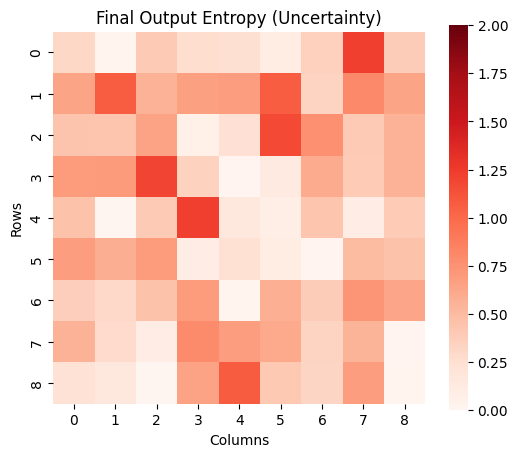

In [ ]:
def calculate_entropy(logits):
    probs = F.softmax(logits, dim=-1)
    entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=-1)
    return entropy

def plot_sudoku_heatmap(data_1d, title="Sudoku Grid Heatmap", cmap='Reds', vmin=0.0, vmax=2.0):
    grid = data_1d.view(9, 9).detach().cpu().numpy()
    plt.figure(figsize=(6, 5))
    # Locked scale prevents the visual illusion of colors shifting between steps
    sns.heatmap(grid, annot=False, cmap=cmap, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()

# Run the model normally to get the final logits
with torch.no_grad():
    # FIXED: Only pass the source board (sample_src)
    final_logits = model(sample_src)

# Calculate entropy for the first sequence in the batch
entropy = calculate_entropy(final_logits[0])

# Plot
plot_sudoku_heatmap(entropy, title="Final Output Entropy (Uncertainty)", cmap="Reds", )

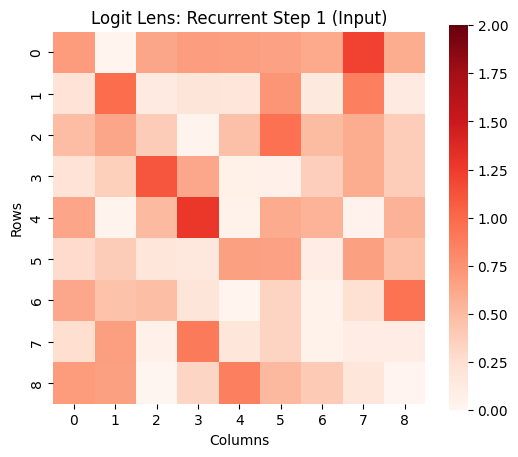

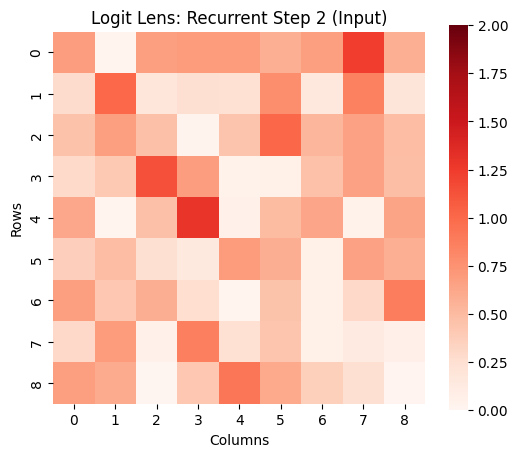

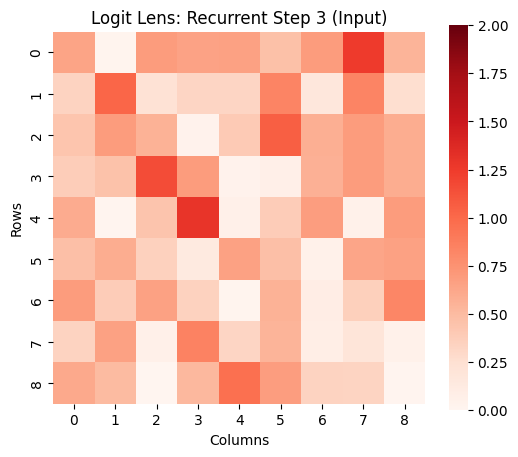

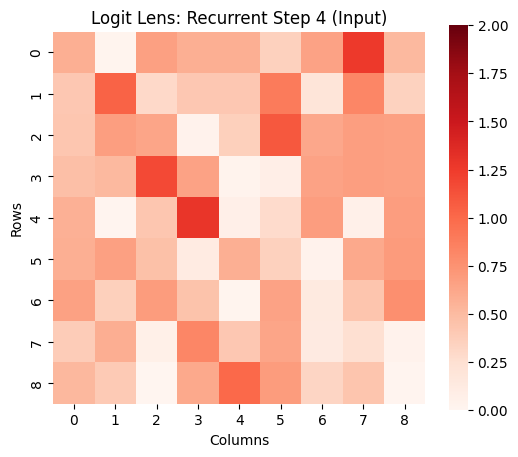

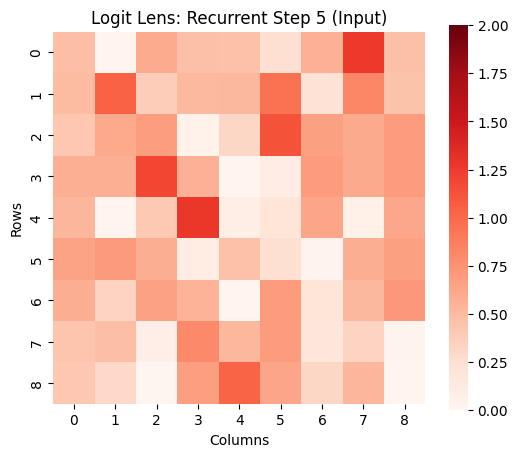

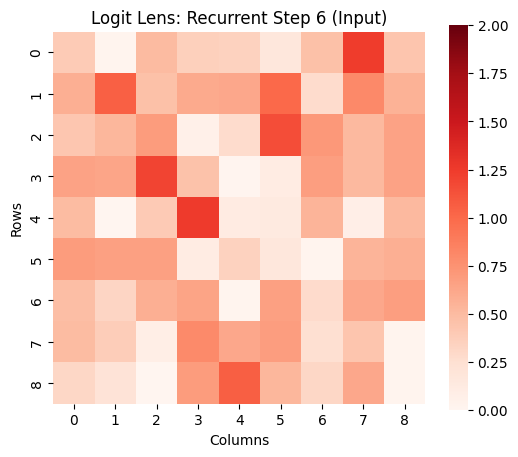

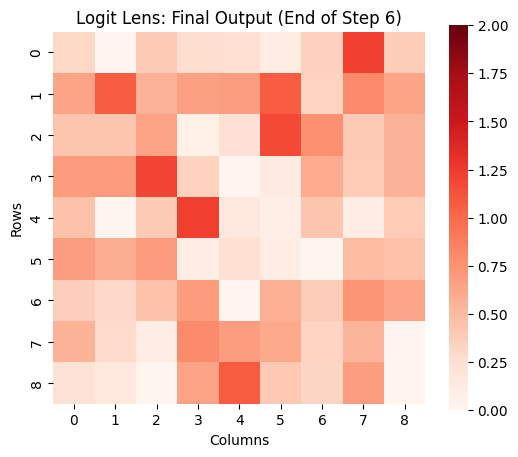

In [ ]:
# ==========================================
# 1. PLOTTING FUNCTION
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def plot_sudoku_heatmap(data_1d, title="Sudoku Grid Heatmap", cmap='Reds', vmin=0.0, vmax=2.3):
    grid = data_1d.view(9, 9).detach().cpu().numpy()
    plt.figure(figsize=(6, 5))
    # Locked scale prevents the visual illusion of colors shifting between steps
    sns.heatmap(grid, annot=False, cmap=cmap, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()

# ==========================================
# 2. RECURRENT LOGIT LENS
# ==========================================
layer_inputs = []
layer_outputs = []

# Define the wiretaps
def capture_input_hook(module, args):
    # args[0] is the data right before it enters the transformer block
    layer_inputs.append(args[0].detach().clone())

def capture_output_hook(module, args, output):
    # output is the data right after it exits the transformer block
    layer_outputs.append(output.detach().clone())

# Attach the wiretaps to your specific recurrent block
h1 = model.transformer_block.register_forward_pre_hook(capture_input_hook)
h2 = model.transformer_block.register_forward_hook(capture_output_hook)

# Run the model normally (the hooks will silently collect the data in the background)
with torch.no_grad():
    final_logits = model(sample_src)

# Remove the wiretaps (crucial so they don't leak memory later)
h1.remove()
h2.remove()

# Combine the data: We want the input at every step, PLUS the very final output
layer_hidden_states = layer_inputs + [layer_outputs[-1]]

# ==========================================
# 3. APPLY UNEMBEDDING AND PLOT
# ==========================================
for i, hidden_state in enumerate(layer_hidden_states):
    # Pass the intercepted hidden state through the final linear layer
    projected_logits = model.fc_out(hidden_state)

    # Calculate entropy for this specific time step
    layer_entropy = calculate_entropy(projected_logits[0])

    # Generate labels dynamically
    if i < len(layer_hidden_states) - 1:
        label = f"Logit Lens: Recurrent Step {i+1} (Input)"
    else:
        label = f"Logit Lens: Final Output (End of Step {model.num_steps})"

    # Explicitly pass the vmin and vmax limits to lock the colors
    plot_sudoku_heatmap(layer_entropy, title=label, cmap="Reds", vmin=0.0, vmax=2)

# Stakced Transformers

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:382: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True



Training started on device: cuda
Epoch 01/100 | Train Loss: 1.5444 | Train Digit Acc: 52.43% | Val Loss: 1.2280 | Val Digit Acc: 56.09%
Epoch 02/100 | Train Loss: 1.2310 | Train Digit Acc: 55.95% | Val Loss: 1.2169 | Val Digit Acc: 56.62%
Epoch 03/100 | Train Loss: 1.2266 | Train Digit Acc: 56.18% | Val Loss: 1.2156 | Val Digit Acc: 56.62%
Epoch 04/100 | Train Loss: 1.2241 | Train Digit Acc: 56.29% | Val Loss: 1.2142 | Val Digit Acc: 56.73%
Epoch 05/100 | Train Loss: 1.2211 | Train Digit Acc: 56.42% | Val Loss: 1.2121 | Val Digit Acc: 56.76%
Epoch 06/100 | Train Loss: 1.2186 | Train Digit Acc: 56.54% | Val Loss: 1.2086 | Val Digit Acc: 56.94%
Epoch 07/100 | Train Loss: 1.2099 | Train Digit Acc: 56.87% | Val Loss: 1.1852 | Val Digit Acc: 57.75%
Epoch 08/100 | Train Loss: 1.0947 | Train Digit Acc: 58.56% | Val Loss: 0.9226 | Val Digit Acc: 60.04%
Epoch 09/100 | Train Loss: 0.9181 | Train Digit Acc: 60.22% | Val Loss: 0.8484 | Val Digit Acc: 62.53%
Epoch 10/100 | Train Loss: 0.8412 | Trai

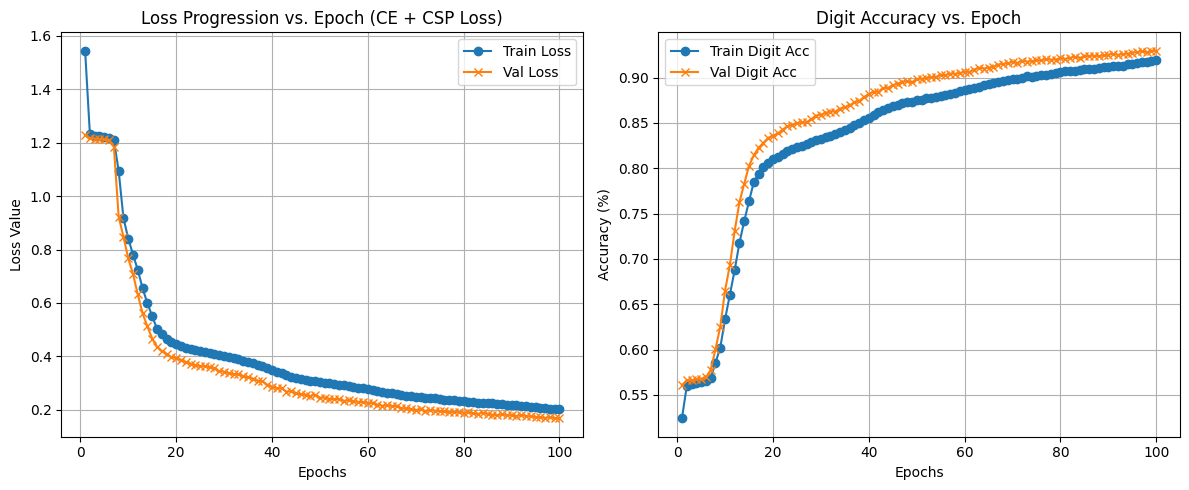

In [ ]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import time
import matplotlib.pyplot as plt

# ==========================================
# 1. DATASET DEFINITION
# ==========================================
class SudokuDataset(Dataset):
    def __init__(self, csv_file, max_samples=10000, start=0):
        """
        Loads the Kaggle Sudoku dataset.
        Columns expected: 'puzzle', 'solution' (81 character strings)
        """
        self.data = pd.read_csv(csv_file, nrows=max_samples, skiprows=range(1, start) if start != 0 else 0)
        self.vocab_size = 10  # 0=blank/unknown, 1-9=digits

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        quiz_str = str(self.data.iloc[idx]['puzzle'])
        sol_str = str(self.data.iloc[idx]['solution'])

        quiz = torch.tensor([int(c) for c in quiz_str], dtype=torch.long)
        sol = torch.tensor([int(c) for c in sol_str], dtype=torch.long)
        return quiz, sol

# ==========================================
# 2. 3D STRUCTURAL POSITIONAL ENCODINGS (UNCHANGED)
# ==========================================
class Sudoku3DPositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.row_embed = nn.Embedding(9, d_model)
        self.col_embed = nn.Embedding(9, d_model)
        self.box_embed = nn.Embedding(9, d_model)

        rows = torch.arange(81) // 9
        cols = torch.arange(81) % 9
        boxes = (rows // 3) * 3 + (cols // 3)

        self.register_buffer('rows', rows)
        self.register_buffer('cols', cols)
        self.register_buffer('boxes', boxes)

    def forward(self, x):
        grid_pos_encoding = (
            self.row_embed(self.rows) +
            self.col_embed(self.cols) +
            self.box_embed(self.boxes)
        )
        return x + grid_pos_encoding.unsqueeze(0)

# ==========================================
# 3. STACKED TRANSFORMER ARCHITECTURE
# ==========================================
class StackedSudokuTransformer(nn.Module):
    def __init__(self, vocab_size=10, d_model=128, nhead=4, num_layers=6):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = Sudoku3DPositionalEncoding(d_model)

        # Stacked architecture: num_layers distinct layers sequentially arranged
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            batch_first=True,
            norm_first=True
        )
        self.transformer_blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, src):
        # src shape: (batch_size, 81)
        x = self.token_embedding(src) * math.sqrt(src.size(-1))
        x = self.pos_encoder(x)

        # Passes data sequentially through all unique layers stacked on top of each other
        x = self.transformer_blocks(x)

        return self.fc_out(x) # Shape: (batch_size, 81, vocab_size)

# ==========================================
# 4. CARDINALITY CONSTRAINT LOSS
# ==========================================
class CardinalityConstraintLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.row_indices = [list(range(i * 9, (i + 1) * 9)) for i in range(9)]
        self.col_indices = [list(range(j, 81, 9)) for j in range(9)]

        self.box_indices = []
        for box_row in range(3):
            for box_col in range(3):
                box = []
                for r in range(box_row * 3, (box_row + 1) * 3):
                    for c in range(box_col * 3, (box_col + 1) * 3):
                        box.append(r * 9 + c)
                self.box_indices.append(box)

    def forward(self, logits):
        probs = torch.softmax(logits, dim=-1)
        digit_probs = probs[:, :, 1:10]

        loss = 0.0

        for indices in self.row_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1)
            loss += torch.mean((group_sum - 1.0) ** 2)

        for indices in self.col_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1)
            loss += torch.mean((group_sum - 1.0) ** 2)

        for indices in self.box_indices:
            group_sum = digit_probs[:, indices, :].sum(dim=1)
            loss += torch.mean((group_sum - 1.0) ** 2)

        return loss / 27.0

# ==========================================
# 5. EXECUTION PIPELINE
# ==========================================
def train_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Model Hyperparameters
    d_model = 128
    nhead = 4
    num_layers = 6  # Total stacked layers depth
    batch_size = 64
    epochs = 100

    csv_path = '/content/drive/MyDrive/Colab Notebooks/sudoku.csv'
    try:
        train_set = SudokuDataset(csv_path, max_samples=10000)
        val_set = SudokuDataset(csv_path, start=10000, max_samples=2000)
    except FileNotFoundError:
        print("Dataset path not found. Please verify your file location.")
        return

    dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    # Updated to load the Stacked architecture configuration
    model = StackedSudokuTransformer(vocab_size=10, d_model=d_model, nhead=nhead, num_layers=num_layers).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

    ce_criterion = nn.CrossEntropyLoss()
    csp_criterion = CardinalityConstraintLoss()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    print(f"Training started on device: {device}")

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        correct_train_digits = 0
        total_train_digits = 0

        for src, target in dataloader:
            src, target = src.to(device), target.to(device)

            optimizer.zero_grad()
            logits = model(src)

            loss_ce = ce_criterion(logits.view(-1, 10), target.view(-1))
            loss_csp = csp_criterion(logits)

            loss = loss_ce + 0.5 * loss_csp
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            preds = logits.argmax(dim=-1)
            correct_train_digits += (preds == target).sum().item()
            total_train_digits += target.numel()

        avg_train_loss = total_train_loss / len(dataloader)
        train_acc = correct_train_digits / total_train_digits
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # Validation Pass
        model.eval()
        total_val_loss = 0
        correct_val_digits = 0
        total_val_digits = 0

        with torch.no_grad():
            for src, target in val_loader:
                src, target = src.to(device), target.to(device)
                logits = model(src)

                loss_ce = ce_criterion(logits.view(-1, 10), target.view(-1))
                loss_csp = csp_criterion(logits)
                loss = loss_ce + 0.5 * loss_csp

                total_val_loss += loss.item()
                preds = logits.argmax(dim=-1)
                correct_val_digits += (preds == target).sum().item()
                total_val_digits += target.numel()

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = correct_val_digits / total_val_digits
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Digit Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Digit Acc: {val_acc*100:.2f}%")

    # ==========================================
    # 6. PLOTTING METRICS
    # ==========================================
    plt.figure(figsize=(12, 5))

    # Subplot 1: Combined Loss Curves
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, epochs + 1), val_losses, label='Val Loss', marker='x')
    plt.title('Loss Progression vs. Epoch (CE + CSP Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.grid(True)
    plt.legend()

    # Subplot 2: Digit Accuracy Curves
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, label='Train Digit Acc', marker='o')
    plt.plot(range(1, epochs + 1), val_accuracies, label='Val Digit Acc', marker='x')
    plt.title('Digit Accuracy vs. Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_pipeline()